# Artificial Neural Networks (ANNs)

## Perceptron

A perceptron is the simplest type of artificial neuron and one of the earliest models in neural networks.

A perceptron takes multiple inputs, applies weights, adds a bias, and passes the result through a step activation function to produce an output.

Mathematically,

$$ z = \sum_{k=1}^K w_k x_k + b $$


$$ z = \mathbf{w}^T \mathbf{x} + b $$

where 

$$ \mathbf{x} = 
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_K
\end{bmatrix}
$$ 

$$ \mathbf{w} = 
\begin{bmatrix}
w_1 \\
w_2 \\
\vdots \\
w_K
\end{bmatrix}
$$ 

$$ \text{K = number of inputs to the perceptron} $$ 

For the classic perceptron, the activation is a step function:

$$ 
\hat{y} = u(z) =
\begin{cases}
1 & \text{if } z \ge 0 \\
0 & \text{if } z < 0
\end{cases}
$$

Components:
- Inputs : $[x_1, x_2, \cdots, x_K] $ &rarr; features
- Weights / Parameters : $[w_1, w_2, \cdots, w_K] $ &rarr; importance of each feature
- Bias : $b$ &rarr; shifts decision boundary
- Activation function : $u(z)$ &rarr; makes final decision

## Sigmoid / Logistic Neuron

A learning algorithm works by making small changes to weights and improving the output step by step. For this to be possible, small changes in weights must lead to small, predictable changes in the network’s output.

In a network of perceptrons, this doesn’t happen because of the step activation. Even a tiny change in weight can flip a neuron’s output from 0 to 1, which can drastically and unpredictably change the entire network’s behavior. This makes gradual learning very difficult.

Sigmoid neurons solve this problem by producing smooth, continuous outputs. Now, small changes in weights cause small changes in output, allowing us to adjust weights gradually and systematically. This is what makes learning through methods like gradient descent and backpropagation possible.

The output of a sigmoid neuron with inputs $x_1, x_2 \cdots, x_K$ and weights $w_1, w_2, \cdots, w_K$, and bias $b$ is

$$ \sigma(z) = \frac{1}{1 + e^{-z}}$$

where
$$ z = \sum_{k=1}^K w_k x_k + b $$

$\sigma(z)$ is called the Sigmoid / Logistic function.




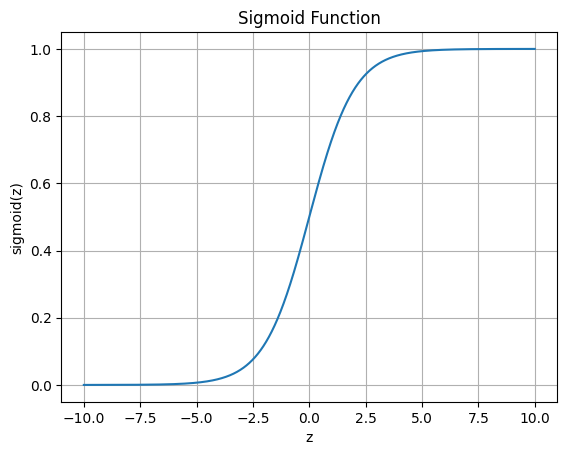

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 10000)   # 10000 points
y = 1 / (1 + np.exp(-z))          # sigmoid function

plt.plot(z, y)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid()
plt.show()

The crucial property is not the specific form of the sigmoid function, but its smoothness: because it is continuous and differentiable, small changes in weights and bias produce small, predictable changes in the output, making it possible to systematically adjust the network parameters and enable effective learning.

## The Architecture of Neural Networks

### Basic Structure of Neural Networks

A neural network consists of layers of neurons:
- Input Layer:
   - First (leftmost) layer
   - Contains input neurons
   - Takes raw data as input (e.g., pixel values)


- Hidden Layer(s):

   - Middle layers
   - Perform intermediate computations
   - Called “hidden” simply because they are neither input nor output

- Output Layer:

   - Final (rightmost) layer
   - Produces the result (prediction/classification)

### Multilayer Perceptron (MLP)

- Networks with multiple layers are often called Multilayer Perceptrons (MLPs).

Important Note:
- Despite the name, they usually use sigmoid (or other smooth) neurons, not perceptrons.
- Terminology is historical and potentially confusing.

### Designing Neural Networks

**Input Layer Design**:
- Determined by the nature of input data
- Example:
   - 64 × 64 grayscale image → 4096 input neurons
   - Each neuron represents a pixel intensity (scaled between 0 and 1)

**Output Layer Design**:
- Depends on the task
- Example:
  - Binary classification → 1 output neuron
     - Output < 0.5 → Class 0
     - Output ≥ 0.5 → Class 1
 
**Hidden Layer Design**:
- Most challenging part
- No strict rules → relies on heuristics
- Trade-offs:
   - More layers/neurons → better learning capacity but slower training
   - Fewer layers → faster but may underfit

### Feedforward Neural Networks (FNN)

- Information flows in one direction only: Input &rarr; Hidden &rarr; Output
- No loops or cycles
- Output of one layer is input to the next
- Most commonly used neural network type

### Recurrent Neural Networks (RNN)

- Allow feedback loops
- Neurons influence future states over time
- Output at time $𝑡$ can affect input at time $t+1$
- Suitable for:
   - Time-series data
   - Sequential data (text, speech)

## Loss / Cost / Objective Function

Mean Square Error (MSE) Loss function:

$$ L(w, b) = \frac{1}{2 m} \sum_{k=1}^m \left\| y - \hat{y} \right\|^2 $$ 
$$ \hat y = \sigma(z) $$
$$ z = \sum w_k x_k + b$$ 

- $w$ : the collection of all weights in the network
- $b$ : all the biases
- $m$ : the total number of training inputs
- $\hat{y} = a $ : is the vector of outputs from the network when $x$ is input
- $x$ : all the training inputs
- $y$ : all the desired outputs corresponding to $x$

The aim of our training algorithm will be to minimize the cost/loss $L(w,b)$ as a function of the weights and biases. In other words, we want to find a set of weights and biases which make the cost as small as possible. We'll do that using an algorithm known as gradient descent.

**Why Loss function?**
- Directly maximizing the number of correctly classified images is difficult because it is not a smooth function of weights and biases. Small changes in parameters usually cause no change in accuracy, making optimization hard.
- To overcome this, a smooth loss function like the MSE is used. Smoothness allows us to determine how small changes in weights and biases affect the output, enabling systematic improvement.
- The MSE is not the only possible choice and may seem ad hoc, but it is sufficient for understanding the fundamentals of learning in neural networks. Other loss functions can be considered later.
- The main training objective is to find weights and biases that minimize the loss function.
- To simplify understanding, the problem is abstracted as:
   - Minimizing a function of many variables
- This leads to the use of gradient descent, a general optimization technique, which will later be applied back to neural networks.

## Taylor Series

For a function $f(x)$, expanded around a point $a$:

$$
f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}(x-a)^n
$$

$$ 
f(x)
= f(a) + f'(a)(x-a) + \frac{f''(a)}{2!} (x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots 
$$

Express it using small change.

Let:
$$ x = a + \Delta x $$

Then:
$$ 
f(a + \Delta x) = f(a) + f'(a) \Delta x + \frac{f''(a)}{2!}(\Delta x)^2 \\
+ \frac{f'''(a)}{3!}(\Delta x)^3 + \cdots
$$

Change in the function:
$$ \Delta f = f(a + \Delta x) - f(a) $$ 

$$ 
\Delta f = f'(a) \Delta x + \frac{f''(a)}{2!}(\Delta x)^2 \\
+ \frac{f'''(a)}{3!}(\Delta x)^3 + \cdots
$$

First-order approximation:
For small $\Delta x$, ignore higher-order terms:

$$
\Delta f = f(x + \Delta x) - f(x)  \approx f'(a) \Delta x
$$

Intuition:
- $f'(a)$ = slope at point $a$
- So, change in function ≈ slope × small step

For multi-variable case:
$$ 
\Delta F = 
F(\mathbf{x} + \Delta \mathbf{x}) - F(\mathbf{x})
$$

$$ 
\Delta F \approx \sum_{i=1}^n \frac{\partial F}{\partial x_i} \Delta x_i
$$

$$
\Delta F \approx  \nabla F \cdot \Delta \mathbf x
$$

where:

$$ \mathbf{x} = [x_1, x_2, \cdots, x_n]^T $$
$$ \Delta \mathbf{x} = [\Delta x_1, \Delta x_2, \cdots, \Delta x_n]^T $$

$$ 
\nabla F = \left[ 
\frac{\partial F}{\partial x_1}, \\ 
\frac{\partial F}{\partial x_2},  \\
\cdots, \\
\frac{\partial F}{\partial x_n} 
\right]^T 
$$


## Gradient Descent Algorithm

$$ \Delta L \approx \nabla L . \Delta \mathbf{w} $$ 

Suppose we choose
$$ \Delta \mathbf{w} = -\eta \nabla L $$

where $\eta$ is a small, positive parameter (known as the learning rate).

Then,
$$
\Delta L \approx -\eta \nabla L \cdot \nabla L = -\eta \| \nabla L \|^2
$$


Because $\| \nabla L \|^2 \ge 0$, this guarantees that $\Delta L \leq 0$, i.e., $L$ will always descrese, never increase, if we change $\mathbf{w}$ according to $\Delta \mathbf{w} = -\eta \nabla L$ within, of course, the limits of the approximation $\Delta L \approx \nabla L \cdot \Delta \mathbf{w}$.  

In gradient descent algorithm, the learning rate ($\eta$) must be chosen carefully.
- If $\eta$ is too large:
   - The approximation used in gradient descent algorithm $\Delta L \approx \nabla L \cdot \Delta \mathbf{w}$ becomes inaccurate
   - The cost may increase ($\Delta L > 0$) instead of decreasing
- If $\eta$ is too small:
   - Parameter updates ($\Delta \mathbf{w}$) become very small
   - Learning becomes very slow
- Therefore, there is a trade-off:
   - $\eta$ should be small enough for accuracy
   - but large enough for reasonable speed
- In practice, $\eta$ is often adjusted dynamically during training to balance stability and speed.

The gradient descent parameter update rule:

$$ 
\mathbf{w}' = \mathbf{w} + \mathbf{\Delta \mathbf{w}} \\
= \mathbf{w} - \eta \nabla L
$$

- By repeatedly updating parameters using gradient descent, the algorithm gradually reduces the loss / cost function.
- Each step moves the parameters in the direction of steepest decrease (negative gradient).
- This process is often described as “rolling down the hill” toward a minimum.
- With enough iterations, the algorithm converges to a minimum (ideally a global or good local minimum)

## Batch Gradient Descent

Loss / Cost function:
$$ L = \frac{1}{n} \sum_x L_x$$
where,
$$ L_x = \frac{1}{2} \| y - \hat{y} \|^2$$

- $x$ : A generic training example from the dataset
- $L_x$ : Loss / Cost corresponding to training example $x$

Batch Gradient Descent uses the entire dataset to compute gradient:
$$ \nabla L = \frac{1}{n} \sum_{j=1}^n \nabla L_j$$
$$n = \text{number of training examples} $$ 

Update rule:

$$ w_k \leftarrow  w_k - \eta \frac{1}{n} \sum_{j=1}^n \frac{\partial L_j}{\partial w_k}$$

$$ b_l \leftarrow  b_l - \eta \frac{1}{n} \sum_{j=1}^n \frac{\partial L_j}{\partial b_l}$$

Characteristics:
- Accurate gradient (exact)
- Slow for large datasets
- Smooth, stable convergence

## Stochastic / Mini-batch Gradient Descent

Uses a random mini-batch of size $m$:

$$ \nabla L \approx \frac{1}{m} \sum_{j=1}^m \nabla L_j$$

- $x_1, x_2, \cdots, x_m$ : A specific randomly selected mini-batch
- $L_j$ : Loss / Cost for the $j^{th}$ sample in the mini-batch

Update rule:
$$ 
w_k \leftarrow w_k - \eta \frac{1}{m} \sum_{j=1}^m\frac {\partial L_j}{\partial w_k}
$$

$$ 
b_l \leftarrow b_l - \eta \frac{1}{m} \sum_{j=1}^m\frac {\partial L_j}{\partial b_l}
$$

Characteristics:
- Approximate (noisy) gradient
- Much faster updates
- Faster learning in practice
- Can fluctuate but often escapes poor local minima

## Online Learning (Incremental Learning)

Online learning is an extreme form of gradient descent where the mini-batch size is 1. That is, the model updates its parameters using one training example at a time.

**Update Rule:**

For a single training example $x$, the parameters are updated as:

$$ w_k \leftarrow w_k - \eta \frac{\partial L_x}{\partial w_k}$$
$$ b_l \leftarrow b_l - \eta \frac{\partial L_x}{\partial b_l}$$

- After processing one example, the model immediately updates
- Then moves to the next example and repeats the process

**How it Works?**
- Pick one training sample
- Compute gradient using only that sample
- Update weights and biases
- Repeat for the next sample
- Continue over the dataset &rarr; completes one epoch

**Advantages:**
- Fast, frequent updates
   - Parameters are updated after every example
   - Can learn quickly in early stages
- Suitable for streaming / real-time data
   - Does not require entire dataset upfront
   - Useful when data arrives continuously
- Low memory requirement
   - Processes one example at a time
 
**Disadvantages:**
- Noisy updates (high variance)
   - Gradient based on a single sample is a poor estimate
   - Causes fluctuations in learning
- Unstable convergence
   - May oscillate around the minimum
   - Harder to settle compared to mini-batch methods
- Less efficient than mini-batch in practice
   - Mini-batch (e.g., size 20–64) provides a better balance of:
      - speed
      - stability